# *$k$-Nearest Neighbors* - $k$-NN

O estudo teórico sobre o assunto do algoritmo do k-NN está disponível no slide. Clique [aqui](https://github.com/pedrothiag/intelligent-systems/blob/main/slides/04_knn.pdf) para acessar o material.

### Implementação Manual do $k$-NN

Vamos realizar a implementação manual do nosso algoritmo do $k$-NN. Para isso, vamos importar nossas bibliotecas padrões:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

#Muda a fonte dos Plots para Arial
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['mathtext.rm'] = "Arial"
plt.rcParams['mathtext.it'] = "Arial:italic"
plt.rcParams['mathtext.bf'] = "Arial:bold"
plt.rcParams['figure.figsize'] = (8, 4)

Para simplificar, vamos criar uma classe para trabalhar com o nosso classificador k-NN.

In [2]:
class KNNClassificador:    
    # Definição da Classe
    def __init__(self, k=3):
        self.k = k
        self.X_treino = None
        self.y_treino = None

    # Função de Treinamento
    def fit(self, X, y):
        self.X_treino = np.array(X)
        self.y_treino = np.array(y)
        return self

    # Função para calcular a distância (euclidiana)
    def _calcular_distancia(self, a, b):
        return np.sqrt(np.sum((a - b)**2))

    # Função para prever um valor
    def _prever_um(self, x):
        # Calcular as distâncias do ponto x até todos os pontos de treinamento
        distancias = np.array([
            self._calcular_distancia(x, x_treino)
            for x_treino in self.X_treino
        ])
        # Dizer quais indices correspondem as menores distâncias
        indices_vizinhos = np.argsort(distancias)[:self.k]
        # Identificar a quais classes pertecem essas menores distâncias
        classes_vizinhos = self.y_treino[indices_vizinhos]
        # Elencar quais classes
        classes_unicas = np.unique(self.y_treino)
        # Criar um dicionário, em que para cada entrada tenho a classe e o valor 
        # é a quantidade de fezes em que a classe aparece na classe_vizinhos
        votos = {c: np.sum(classes_vizinhos == c) for c in classes_unicas}
        # Retorna a classe com maior valor
        return max(votos, key=votos.get)

    # Função para prever uma grande quantidade de valores
    def predict(self, X):
        X = np.array(X)
        return np.array([self._prever_um(x) for x in X])

Vamos carregar o *dataset* que corresponde a vários tipos de flor de íris. Ele contém 150 instâncias (flores) com 4 características (largura/comprimento da sépala e pétala) e 3 classes de espécies (setosa, versucikir e virginica). O objetivo clássico ao utilizar este conjunto de dados é prever a espécie da flor com base nas suas características.

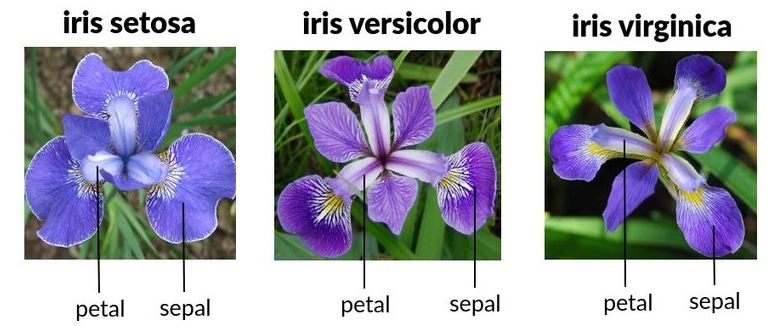

In [4]:
iris = load_iris()
X, y = iris.data, iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [5]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


Vamos dividir nosso *dataset* em treinamento e teste:

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 105 amostras
Teste:  45 amostras


E agora vamos treinar nosso algoritmo de k-NN com as informações:

In [7]:
meu_knn = KNNClassificador(k=5)
meu_knn.fit(X_train, y_train)

Podemos realizar as previsões para novos valores e determinar a matriz de confusão do nosso classificador:

In [8]:
y_prev = meu_knn.predict(X_test)
print(confusion_matrix(y_prev, y_test))

[[15  0  0]
 [ 0 15  1]
 [ 0  0 14]]


Poderemos também determinar a acurácia do nosso classificador:

In [9]:
print(f"Acurácia: {accuracy_score(y_test, y_prev):.4f}")

Acurácia: 0.9778


### Implementação do $k$-NN com a `sklearn`

A biblioteca `sklearn` possui as implementações prontas para o k-NN. No caso, utilizaremos a classe `KNeighborsClassifier` e poderemos utilizar o método `fit` para realizar o treinamento do nosso modelo:

In [11]:
sklearn_knn = KNeighborsClassifier(n_neighbors=5)
sklearn_knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Podemos prever os valores do conjunto de testes utilizando o método `predict`, bem como escrever a matriz de confusão e determinar a acuária do classificador:

In [12]:
y_prev_sklearn = sklearn_knn.predict(X_test)
print(confusion_matrix(y_prev_sklearn, y_test))

[[15  0  0]
 [ 0 15  1]
 [ 0  0 14]]


In [13]:
print(f"Acurácia: {accuracy_score(y_test, y_prev_sklearn):.4f}")

Acurácia: 0.9778
